In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_score,
                              recall_score, f1_score)

In [2]:
data1 = pd.read_csv("AI-based Career Recommendation System.csv")
data2 = pd.read_csv("data-final.csv", sep="\t")
data3 = pd.read_csv("enhanced_student_habits_performance_dataset.csv")

print("Dataset 1 shape:", data1.shape)
print("Dataset 2 shape:", data2.shape)
print("Dataset 3 shape:", data3.shape)

Dataset 1 shape: (200, 8)
Dataset 2 shape: (1015341, 110)
Dataset 3 shape: (80000, 31)


In [3]:
career_core = data1[["Skills", "Interests", "Recommended_Career"]].copy()

def has_keyword(text, keyword):
    if pd.isna(text):
        return 0
    return int(keyword.lower() in str(text).lower())


In [4]:
career_features_raw = pd.DataFrame({
    "tech_interest":     career_core["Interests"].apply(lambda x: has_keyword(x, "tech")),
    "data_interest":     career_core["Interests"].apply(lambda x: has_keyword(x, "data")),
    "creative_interest": career_core["Interests"].apply(lambda x: has_keyword(x, "design")),
    "business_interest": career_core["Interests"].apply(lambda x: has_keyword(x, "business")),
    "people_interest":   career_core["Interests"].apply(lambda x: has_keyword(x, "people")),
})

In [5]:
career_features = career_features_raw.sample(5000, replace=True, random_state=42).reset_index(drop=True)

print("Career features shape:", career_features.shape)
print("\nSample career features:")
print(career_features.head())

Career features shape: (5000, 5)

Sample career features:
   tech_interest  data_interest  creative_interest  business_interest  \
0              0              0                  0                  0   
1              0              0                  1                  0   
2              0              0                  0                  0   
3              1              0                  0                  0   
4              0              0                  0                  0   

   people_interest  
0                0  
1                0  
2                0  
3                0  
4                0  


In [6]:
big5_items = data2.iloc[:, :50].copy().apply(pd.to_numeric, errors="coerce")

big5_all = pd.DataFrame({
    "Extraversion":      big5_items.filter(regex="^EXT").mean(axis=1),
    "Neuroticism":       big5_items.filter(regex="^EST").mean(axis=1),
    "Agreeableness":     big5_items.filter(regex="^AGR").mean(axis=1),
    "Conscientiousness": big5_items.filter(regex="^CSN").mean(axis=1),
    "Openness":          big5_items.filter(regex="^OPN").mean(axis=1),
}).dropna()

In [7]:
big5_all = (big5_all / 5.0).clip(0, 1)

big5_traits = big5_all.sample(5000, random_state=42).reset_index(drop=True)

print("Big5 traits shape:", big5_traits.shape)
print("\nBig5 stats:")
print(big5_traits.describe().round(3))

Big5 traits shape: (5000, 5)

Big5 stats:
       Extraversion  Neuroticism  Agreeableness  Conscientiousness  Openness
count      5000.000     5000.000       5000.000           5000.000  5000.000
mean          0.607        0.609          0.631              0.624     0.651
std           0.073        0.131          0.075              0.082     0.081
min           0.000        0.000          0.000              0.000     0.000
25%           0.560        0.520          0.580              0.580     0.600
50%           0.600        0.600          0.640              0.620     0.660
75%           0.640        0.700          0.680              0.680     0.700
max           1.000        1.000          1.000              1.000     1.000


In [8]:
habits_raw = data3[[
    "study_hours_per_day", "attendance_percentage",
    "motivation_level", "time_management_score",
    "extracurricular_participation", "stress_level", "learning_style"
]].copy()

In [9]:
habits_raw["extracurricular_participation"] = habits_raw["extracurricular_participation"].map({"Yes": 1, "No": 0})
habits_raw["learning_style"] = habits_raw["learning_style"].astype("category").cat.codes


In [10]:
scaler_habits = MinMaxScaler()
num_cols = ["study_hours_per_day", "attendance_percentage", "motivation_level", "time_management_score", "stress_level"]
habits_raw[num_cols] = scaler_habits.fit_transform(habits_raw[num_cols])

In [11]:
habits_features = habits_raw.sample(5000, random_state=42).reset_index(drop=True)

print("Habits features shape:", habits_features.shape)


Habits features shape: (5000, 7)


In [12]:
X = pd.concat([career_features, big5_traits, habits_features], axis=1)

print("\nFinal X shape:", X.shape)
print("Null values in X:", X.isnull().sum().sum())
print("\nAll feature columns:")
print(X.columns.tolist())


Final X shape: (5000, 17)
Null values in X: 0

All feature columns:
['tech_interest', 'data_interest', 'creative_interest', 'business_interest', 'people_interest', 'Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness', 'study_hours_per_day', 'attendance_percentage', 'motivation_level', 'time_management_score', 'extracurricular_participation', 'stress_level', 'learning_style']


In [13]:
def assign_career(row):
    if row["tech_interest"] == 1 and row["Openness"] > 0.6:
        return "Technology & Engineering"
    if row["data_interest"] == 1 and row["Conscientiousness"] > 0.6:
        return "Data & Analytics"
    if row["creative_interest"] == 1 and row["Openness"] > 0.6:
        return "Creative & Design"
    if row["business_interest"] == 1 and row["Extraversion"] > 0.5:
        return "Business & Strategy"
    # Default: anyone else → Education
    return "Education & Social Impact"

In [14]:
y = X.apply(assign_career, axis=1)

print("Label distribution (rule-based):")
print(y.value_counts())
print("\nNOTE: These labels are derived from X features → expect ~100% accuracy")

Label distribution (rule-based):
Education & Social Impact    2901
Technology & Engineering      959
Business & Strategy           575
Creative & Design             394
Data & Analytics              171
Name: count, dtype: int64

NOTE: These labels are derived from X features → expect ~100% accuracy


In [15]:
def entropy(series):
    probs = series.value_counts(normalize=True)
    return float(-np.sum(probs * np.log2(probs + 1e-9)))

def gini_index(series):
    probs = series.value_counts(normalize=True)
    return float(1 - np.sum(probs ** 2))

def information_gain(X_df, y_series, feature):
    total_entropy = entropy(y_series)
    col = X_df[feature].copy()
    unique_vals = col.dropna().unique()
    if len(unique_vals) > 5:
        median = col.median()
        col = (col >= median).astype(int)
        unique_vals = [0, 1]
    weighted_entropy = 0
    for val in unique_vals:
        subset = y_series[col == val]
        if len(subset) == 0:
            continue
        weight = len(subset) / len(y_series)
        weighted_entropy += weight * entropy(subset)
    return round(total_entropy - weighted_entropy, 6)

H_total = entropy(y)
G_total = gini_index(y)

In [16]:
print("DATASET PURITY MEASURES (before any split)")
print("=" * 50)
print(f"Shannon Entropy : {H_total:.4f} bits")
print(f"Gini Index      : {G_total:.4f}")
print(f"Number of classes: {y.nunique()}")
print(f"Max possible entropy: {np.log2(y.nunique()):.4f} bits")

DATASET PURITY MEASURES (before any split)
Shannon Entropy : 1.7268 bits
Gini Index      : 0.6060
Number of classes: 5
Max possible entropy: 2.3219 bits


In [17]:
ig_scores = {feat: information_gain(X, y, feat) for feat in X.columns}
ig_df = (pd.DataFrame.from_dict(ig_scores, orient="index", columns=["Information_Gain"])
           .sort_values("Information_Gain", ascending=False))

print("\nInformation Gain per feature (sorted):")
print(ig_df.round(6).to_string())


Information Gain per feature (sorted):
                               Information_Gain
tech_interest                          0.486315
business_interest                      0.444137
creative_interest                      0.295523
data_interest                          0.191203
Openness                               0.049366
Conscientiousness                      0.036747
learning_style                         0.002259
Neuroticism                            0.001926
attendance_percentage                  0.001903
Agreeableness                          0.001743
Extraversion                           0.001066
time_management_score                  0.000875
extracurricular_participation          0.000632
stress_level                           0.000589
motivation_level                       0.000455
study_hours_per_day                    0.000354
people_interest                        0.000000


In [18]:
print(f"\nTop root node feature: '{ig_df.index[0]}' (IG={ig_df.iloc[0,0]:.6f})")



Top root node feature: 'tech_interest' (IG=0.486315)


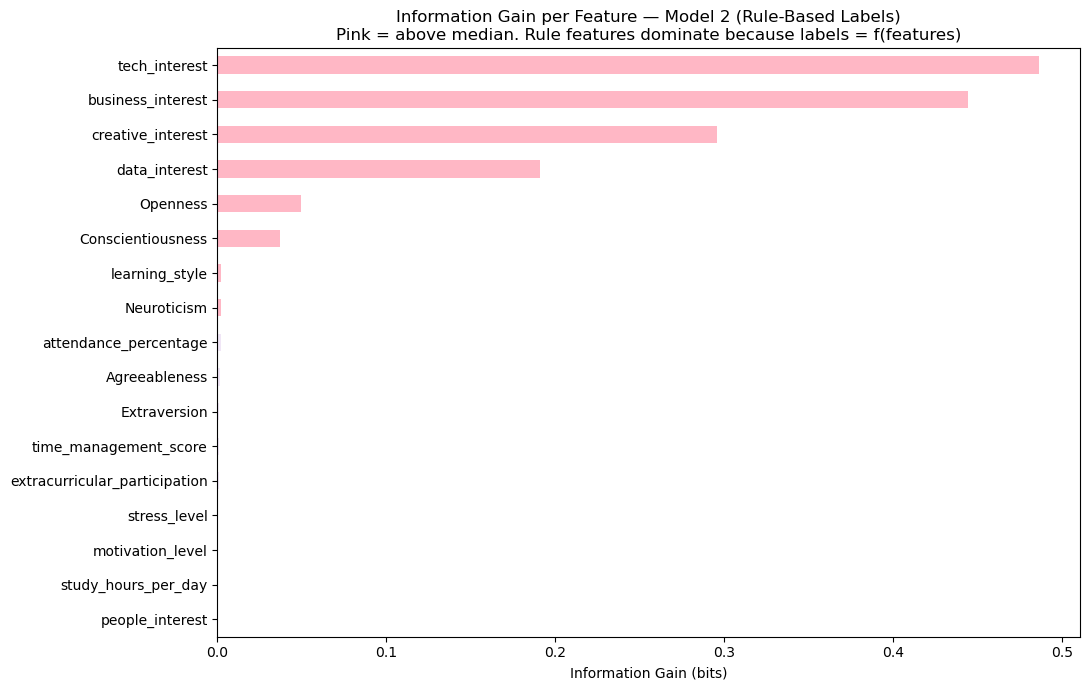

In [19]:
plt.figure(figsize=(11, 7))
colors = ['#FFB7C5' if ig > ig_df['Information_Gain'].median() else '#F0E6F6'
          for ig in ig_df['Information_Gain']]
ig_df['Information_Gain'].plot(kind='barh', color=colors)
plt.xlabel("Information Gain (bits)")
plt.title("Information Gain per Feature — Model 2 (Rule-Based Labels)\n"
          "Pink = above median. Rule features dominate because labels = f(features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [21]:
print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print("\nClass distribution in training set:")
print(y_train.value_counts())

Training set : (4000, 17)
Test set     : (1000, 17)

Class distribution in training set:
Education & Social Impact    2321
Technology & Engineering      767
Business & Strategy           460
Creative & Design             315
Data & Analytics              137
Name: count, dtype: int64


In [22]:
numeric_features = X.columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # Step A: fill NaN with median
    ("scaler",  StandardScaler())                    # Step B: zero mean, unit variance
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features)
])




In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [24]:
dt_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",     # Step 1+2: entropy for purity + root selection
        max_depth=5,             # Step 4:   pre-pruning (5 levels enough for 4 rules)
        min_samples_split=30,    # Step 4:   pre-pruning (node needs 30+ samples)
        min_samples_leaf=15,     # Step 4:   pre-pruning (leaf needs 15+ samples)
        random_state=42
    ))
])

In [25]:
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

In [26]:
dt_train_acc = dt_pipeline.score(X_train, y_train)
dt_test_acc  = accuracy_score(y_test, y_pred_dt)
dt_prec      = precision_score(y_test, y_pred_dt, average="weighted", zero_division=0)
dt_rec       = recall_score(y_test, y_pred_dt, average="weighted", zero_division=0)
dt_f1        = f1_score(y_test, y_pred_dt, average="weighted", zero_division=0)


In [27]:
print("\n--- Decision Tree Results ---")
print(f"Train Accuracy : {dt_train_acc:.4f}  ← reconstructed the rules")
print(f"Test  Accuracy : {dt_test_acc:.4f}")
print(f"Precision      : {dt_prec:.4f}")
print(f"Recall         : {dt_rec:.4f}")
print(f"F1 Score       : {dt_f1:.4f}")
print(f"Overfit Gap    : {dt_train_acc - dt_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))


--- Decision Tree Results ---
Train Accuracy : 0.9995  ← reconstructed the rules
Test  Accuracy : 1.0000
Precision      : 1.0000
Recall         : 1.0000
F1 Score       : 1.0000
Overfit Gap    : -0.0005

Classification Report:
                           precision    recall  f1-score   support

      Business & Strategy       1.00      1.00      1.00       115
        Creative & Design       1.00      1.00      1.00        79
         Data & Analytics       1.00      1.00      1.00        34
Education & Social Impact       1.00      1.00      1.00       580
 Technology & Engineering       1.00      1.00      1.00       192

                 accuracy                           1.00      1000
                macro avg       1.00      1.00      1.00      1000
             weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
[[115   0   0   0   0]
 [  0  79   0   0   0]
 [  0   0  34   0   0]
 [  0   0   0 580   0]
 [  0   0   0   0 192]]


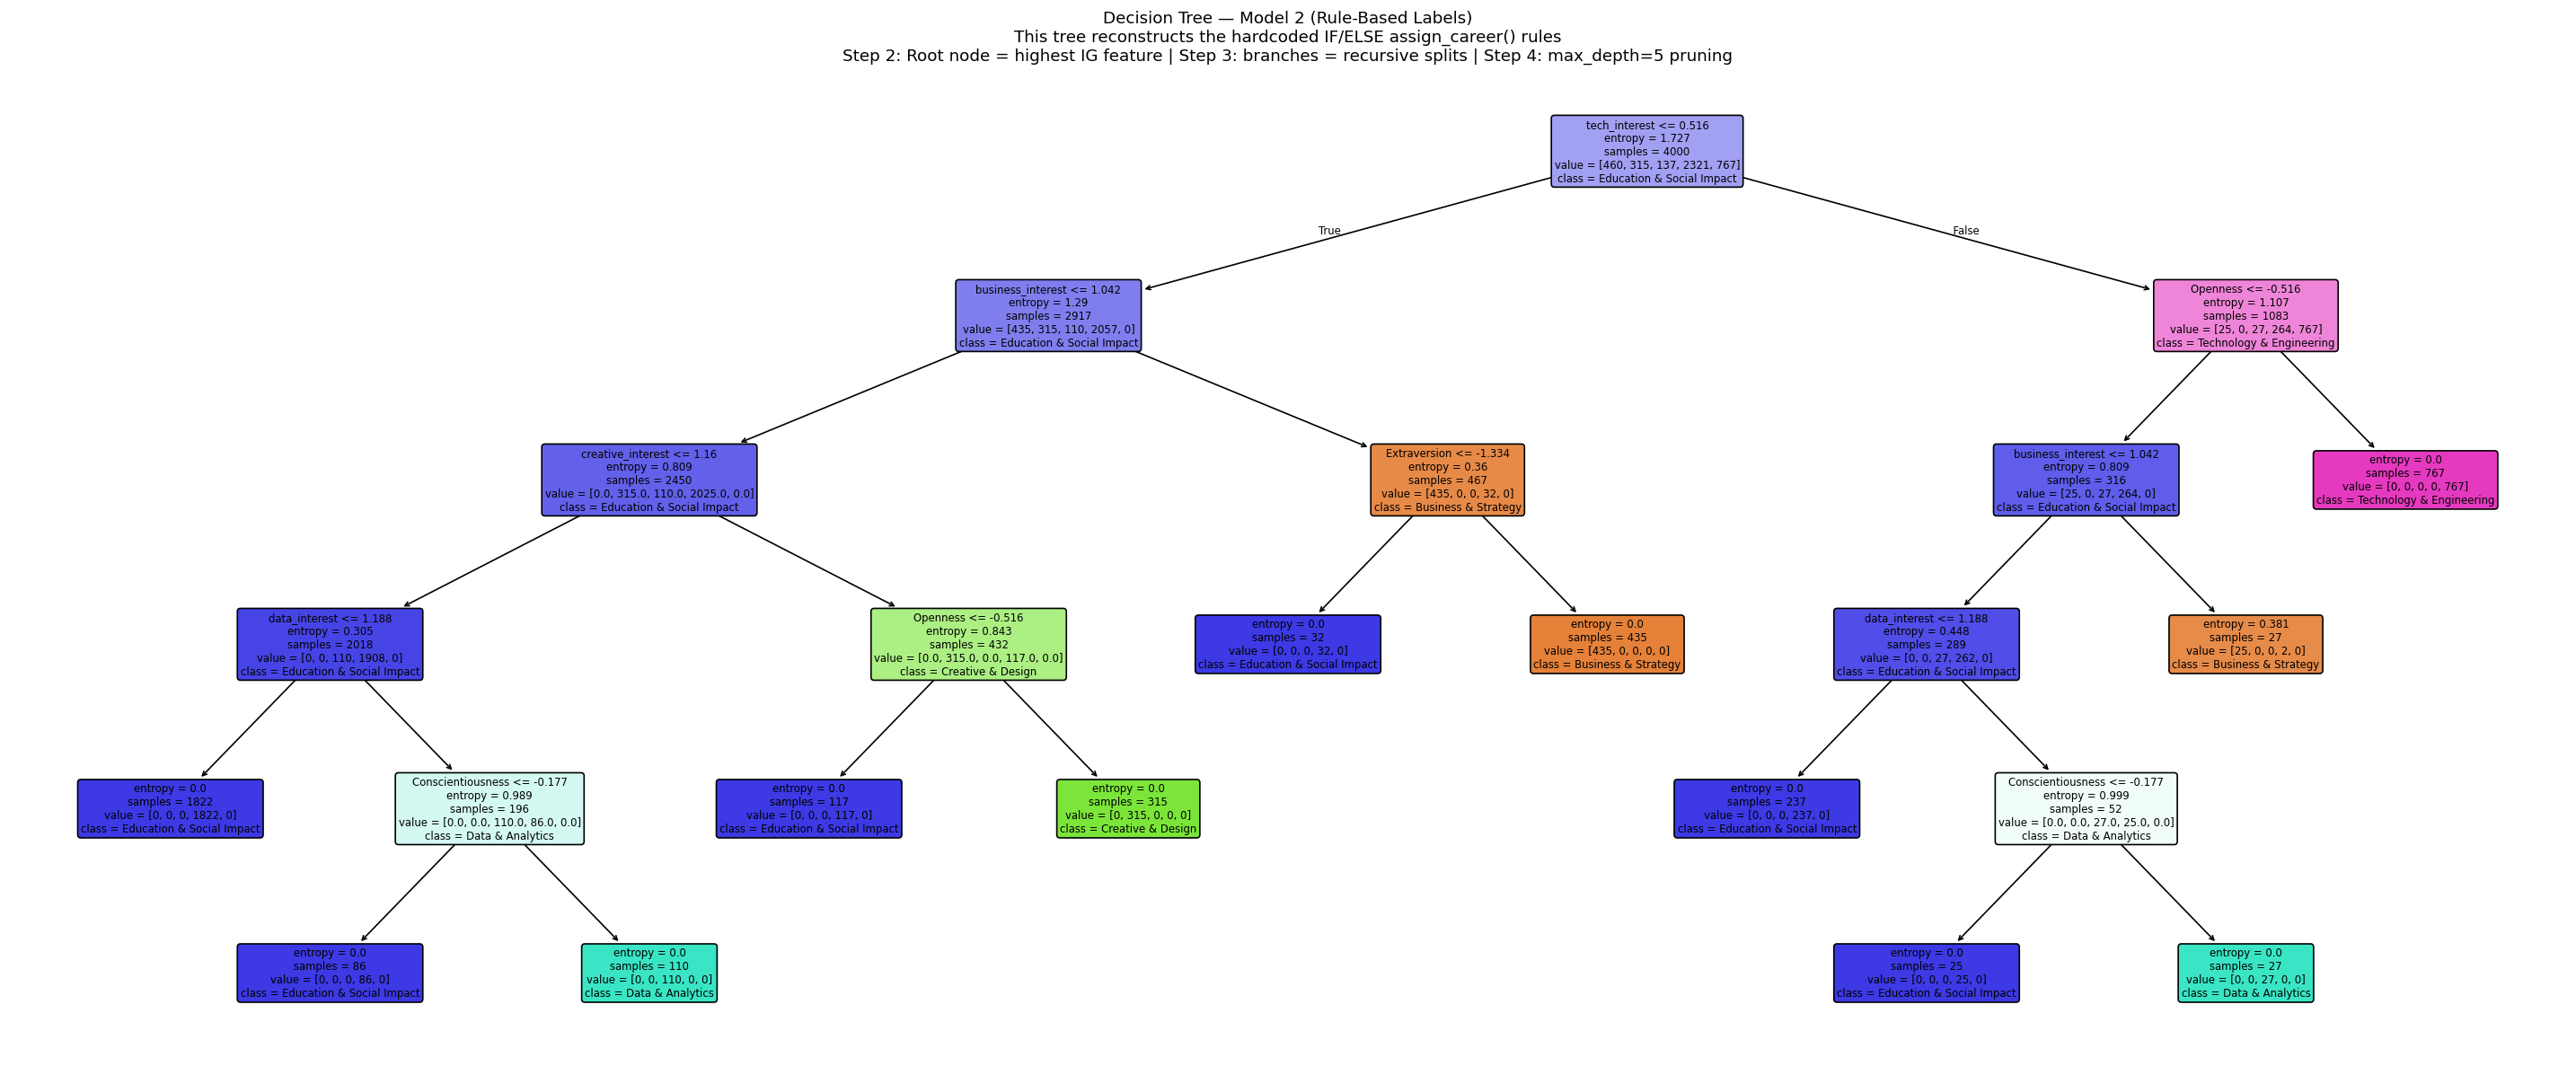

In [28]:
fig, ax = plt.subplots(figsize=(24, 10), dpi=120)
plot_tree(
    dt_pipeline.named_steps["classifier"],
    feature_names=numeric_features,
    class_names=sorted(y.unique()),
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax
)
plt.title("Decision Tree — Model 2 (Rule-Based Labels)\n"
          "This tree reconstructs the hardcoded IF/ELSE assign_career() rules\n"
          "Step 2: Root node = highest IG feature | Step 3: branches = recursive splits | Step 4: max_depth=5 pruning",
          fontsize=11)
plt.tight_layout()
plt.show()


In [29]:
dt_cv_scores = cross_val_score(dt_pipeline, X_train, y_train, cv=cv, scoring="accuracy")

print("\nDecision Tree — 5-Fold Cross-Validation:")
print(f"  Scores : {dt_cv_scores.round(4)}")
print(f"  Mean   : {dt_cv_scores.mean():.4f}")
print(f"  Std    : {dt_cv_scores.std():.4f}")



Decision Tree — 5-Fold Cross-Validation:
  Scores : [1.     1.     0.9988 1.     0.9988]
  Mean   : 0.9995
  Std    : 0.0006


In [30]:
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,        # Step 1: 200 bootstrap subsets → 200 trees
        max_depth=8,             # each tree pruned (individual overfit prevention)
        min_samples_split=30,
        min_samples_leaf=15,
        max_features="sqrt",     # Step 2: sqrt(n_features) random features per split
        bootstrap=True,          # Step 1: enable bootstrap sampling
        oob_score=True,          # Step 1: compute OOB accuracy (free internal validation)
        random_state=42,
        n_jobs=-1                # Step 3: parallel training on all CPU cores
    ))
])


In [31]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [32]:
rf_train_acc = rf_pipeline.score(X_train, y_train)
rf_test_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec      = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_rec       = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_f1        = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_oob       = rf_pipeline.named_steps["classifier"].oob_score_


In [33]:
print("\n--- Random Forest Results ---")
print(f"Train Accuracy  : {rf_train_acc:.4f}")
print(f"Test  Accuracy  : {rf_test_acc:.4f}")
print(f"OOB Score       : {rf_oob:.4f}  ← Step 1: free OOB internal validation")
print(f"Precision       : {rf_prec:.4f}")
print(f"Recall          : {rf_rec:.4f}")
print(f"F1 Score        : {rf_f1:.4f}")
print(f"Overfit Gap     : {rf_train_acc - rf_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


--- Random Forest Results ---
Train Accuracy  : 0.9982
Test  Accuracy  : 0.9960
OOB Score       : 0.9912  ← Step 1: free OOB internal validation
Precision       : 0.9960
Recall          : 0.9960
F1 Score        : 0.9959
Overfit Gap     : 0.0022

Classification Report:
                           precision    recall  f1-score   support

      Business & Strategy       1.00      1.00      1.00       115
        Creative & Design       1.00      1.00      1.00        79
         Data & Analytics       1.00      0.88      0.94        34
Education & Social Impact       0.99      1.00      1.00       580
 Technology & Engineering       1.00      1.00      1.00       192

                 accuracy                           1.00      1000
                macro avg       1.00      0.98      0.99      1000
             weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
[[115   0   0   0   0]
 [  0  79   0   0   0]
 [  0   0  30   4   0]
 [  0   0   0 580   0]
 [  0   0   0 

In [34]:
rf_importances = pd.Series(
    rf_pipeline.named_steps["classifier"].feature_importances_,
    index=numeric_features
).sort_values(ascending=False)

In [35]:
print("\nStep 4 — Feature Importances from Majority Voting (top 10):")
print(rf_importances.head(10).round(4))



Step 4 — Feature Importances from Majority Voting (top 10):
tech_interest            0.3127
business_interest        0.2639
Openness                 0.1473
creative_interest        0.1455
data_interest            0.0662
Conscientiousness        0.0240
Extraversion             0.0105
attendance_percentage    0.0053
study_hours_per_day      0.0047
time_management_score    0.0047
dtype: float64


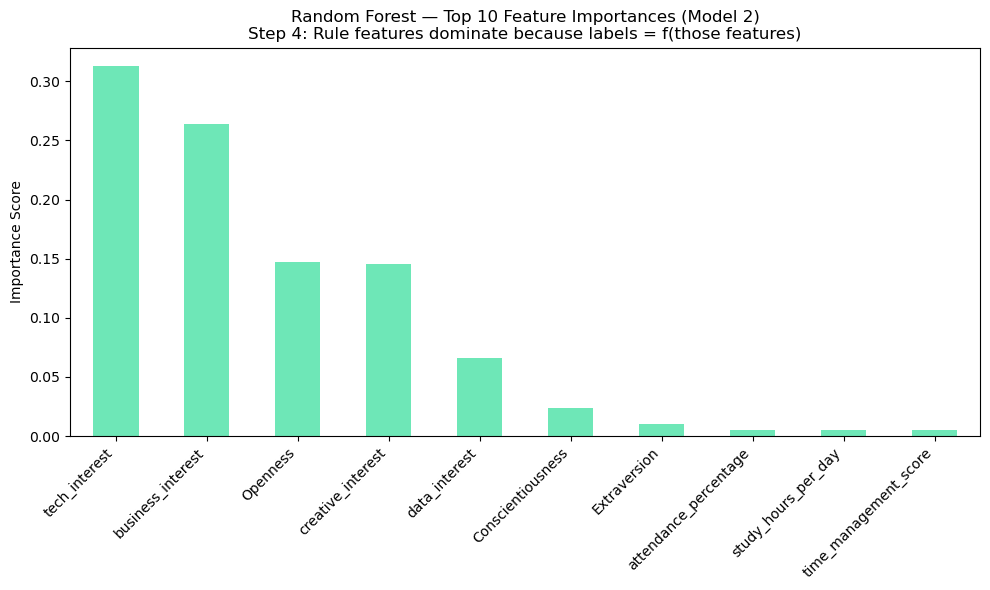

In [36]:
plt.figure(figsize=(10, 6))
rf_importances.head(10).plot(kind="bar", color="#6EE7B7")
plt.title("Random Forest — Top 10 Feature Importances (Model 2)\n"
          "Step 4: Rule features dominate because labels = f(those features)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring="accuracy")

print("\nRandom Forest — 5-Fold Cross-Validation:")
print(f"  Scores : {rf_cv_scores.round(4)}")
print(f"  Mean   : {rf_cv_scores.mean():.4f}")
print(f"  Std    : {rf_cv_scores.std():.4f}")


Random Forest — 5-Fold Cross-Validation:
  Scores : [0.9925 0.9925 0.98   0.9875 0.9838]
  Mean   : 0.9872
  Std    : 0.0049


In [38]:
print("ADABOOST — Building Step by Step")
print("=" * 50)

n_samples = len(X_train)

print(f"\nStep 1: Initialize Weights")
print(f"  Training samples (N)  : {n_samples}")
print(f"  Initial weight/sample : 1/N = 1/{n_samples} = {1/n_samples:.8f}")
print(f"  Total weight sum      : {n_samples} × {1/n_samples:.8f} = 1.0")
print(f"  All career records start equally important")

ADABOOST — Building Step by Step

Step 1: Initialize Weights
  Training samples (N)  : 4000
  Initial weight/sample : 1/N = 1/4000 = 0.00025000
  Total weight sum      : 4000 × 0.00025000 = 1.0
  All career records start equally important


In [39]:
base_stump = DecisionTreeClassifier(
    max_depth=2,           # Step 2: shallow weak learner (stump)
    min_samples_leaf=20,   # Step 2: each stump leaf needs 20+ samples
    random_state=42
)

ada_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", AdaBoostClassifier(
        estimator=base_stump,  # Step 2: the weak learner stump
        n_estimators=150,      # Step 6: 150 sequential boosting rounds
        learning_rate=0.5,     # Step 6: scale each stump's α by 0.5
        random_state=42
    ))
])


In [40]:
ada_pipeline.fit(X_train, y_train)
y_pred_ada = ada_pipeline.predict(X_test)

In [41]:
ada_train_acc = ada_pipeline.score(X_train, y_train)
ada_test_acc  = accuracy_score(y_test, y_pred_ada)
ada_prec      = precision_score(y_test, y_pred_ada, average="weighted", zero_division=0)
ada_rec       = recall_score(y_test, y_pred_ada, average="weighted", zero_division=0)
ada_f1        = f1_score(y_test, y_pred_ada, average="weighted", zero_division=0)

In [42]:
print("\n--- AdaBoost Results ---")
print(f"Train Accuracy : {ada_train_acc:.4f}  ← Steps 3-5 converged on the rules perfectly")
print(f"Test  Accuracy : {ada_test_acc:.4f}   ← Step 6 weighted voting reproduces rules")
print(f"Precision      : {ada_prec:.4f}")
print(f"Recall         : {ada_rec:.4f}")
print(f"F1 Score       : {ada_f1:.4f}")
print(f"Overfit Gap    : {ada_train_acc - ada_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))
print("\nNote: ~100% accuracy because labels = f(features) (label leakage)")
print("The model learned exactly what we told it to learn.")


--- AdaBoost Results ---
Train Accuracy : 1.0000  ← Steps 3-5 converged on the rules perfectly
Test  Accuracy : 1.0000   ← Step 6 weighted voting reproduces rules
Precision      : 1.0000
Recall         : 1.0000
F1 Score       : 1.0000
Overfit Gap    : 0.0000

Classification Report:
                           precision    recall  f1-score   support

      Business & Strategy       1.00      1.00      1.00       115
        Creative & Design       1.00      1.00      1.00        79
         Data & Analytics       1.00      1.00      1.00        34
Education & Social Impact       1.00      1.00      1.00       580
 Technology & Engineering       1.00      1.00      1.00       192

                 accuracy                           1.00      1000
                macro avg       1.00      1.00      1.00      1000
             weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[115   0   0   0   0]
 [  0  79   0   0   0]
 [  0   0  34   0   0]
 [  0   0   0 580   0]

In [43]:
ada_cv_scores = cross_val_score(ada_pipeline, X_train, y_train, cv=cv, scoring="accuracy")

print("\nAdaBoost — 5-Fold Cross-Validation:")
print(f"  Scores : {ada_cv_scores.round(4)}")
print(f"  Mean   : {ada_cv_scores.mean():.4f}")
print(f"  Std    : {ada_cv_scores.std():.4f}")


AdaBoost — 5-Fold Cross-Validation:
  Scores : [1. 1. 1. 1. 1.]
  Mean   : 1.0000
  Std    : 0.0000


In [44]:
comparison = pd.DataFrame({
    "Model":         ["Decision Tree", "Random Forest", "AdaBoost"],
    "Train Acc":     [dt_train_acc, rf_train_acc, ada_train_acc],
    "Test Acc":      [dt_test_acc,  rf_test_acc,  ada_test_acc],
    "CV Mean":       [dt_cv_scores.mean(), rf_cv_scores.mean(), ada_cv_scores.mean()],
    "CV Std":        [dt_cv_scores.std(),  rf_cv_scores.std(),  ada_cv_scores.std()],
    "Overfit Gap":   [dt_train_acc - dt_test_acc,
                      rf_train_acc - rf_test_acc,
                      ada_train_acc - ada_test_acc],
    "Precision":     [dt_prec, rf_prec, ada_prec],
    "Recall":        [dt_rec,  rf_rec,  ada_rec],
    "F1":            [dt_f1,   rf_f1,   ada_f1],
}).round(4)


MODEL COMPARISON — Model 2 (Rule-Based Labels, ~100% Accuracy)
        Model  Train Acc  Test Acc  CV Mean  CV Std  Overfit Gap  Precision  Recall     F1
Decision Tree     0.9995     1.000   0.9995  0.0006      -0.0005      1.000   1.000 1.0000
Random Forest     0.9982     0.996   0.9872  0.0049       0.0022      0.996   0.996 0.9959
     AdaBoost     1.0000     1.000   1.0000  0.0000       0.0000      1.000   1.000 1.0000


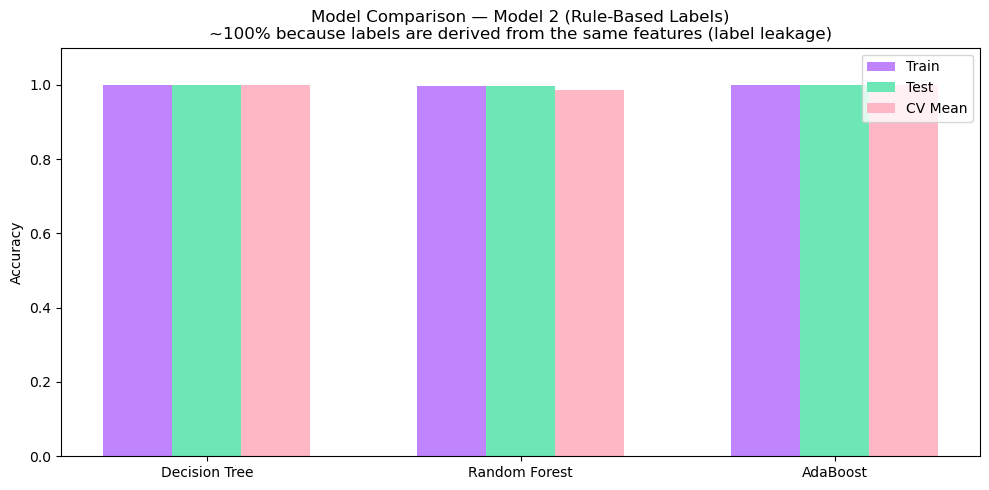

In [45]:
print("MODEL COMPARISON — Model 2 (Rule-Based Labels, ~100% Accuracy)")
print("=" * 65)
print(comparison.to_string(index=False))

x = np.arange(3)
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.22
ax.bar(x - w, comparison["Train Acc"], w, label="Train",   color="#C084FC")
ax.bar(x,     comparison["Test Acc"],  w, label="Test",    color="#6EE7B7")
ax.bar(x + w, comparison["CV Mean"],   w, label="CV Mean", color="#FFB7C5")
ax.set_xticks(x)
ax.set_xticklabels(["Decision Tree", "Random Forest", "AdaBoost"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title("Model Comparison — Model 2 (Rule-Based Labels)\n"
             "~100% because labels are derived from the same features (label leakage)")
plt.tight_layout()
plt.show()

In [46]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(ada_pipeline, "models/exploration_pipeline_m2.pkl")
print("Saved: models/exploration_pipeline_m2.pkl")
print("\nColumn order Flask must send:")
print(X.columns.tolist())

Saved: models/exploration_pipeline_m2.pkl

Column order Flask must send:
['tech_interest', 'data_interest', 'creative_interest', 'business_interest', 'people_interest', 'Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness', 'study_hours_per_day', 'attendance_percentage', 'motivation_level', 'time_management_score', 'extracurricular_participation', 'stress_level', 'learning_style']
